In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Introduction

This project performs Exploratory Data Analysis(EDA) on  a retail sales,dataset containing information about 'Product_Type','Net_Quantity','Gross_Sales',

'Discounts','Returns',and 'Total_Sales'

This goal analyze is to:

1)Understand overall sales performance

2)Identify trends in product categories

3)analyze the impact of discounts and Returns

4)Detect zero or negative sales and remove outliers


## Case Study / Problem Statement

Retail sales often face challenges such as :

1)High product returns 

2)Heavy discounting reducing profit

3)some product categories underperforming

4)Negative or zero net sales

The aim is to uncover insights that can support better sales and inventory strategies.

### Dataset Description 

The dataset contains 1,775 rows and 6 columns:

|  Column Name            |   Description                            |
|-------------------------|------------------------------------------|
|  Product_Type           |  Category of product                     |      
|  Net_Quantity           | Quantity sold after return               |
|Gross_Sales              | Total sales before discount              | 
| Discounts               |  Discount amount (negative values)       |
|Revenue                  | Returned product value (negative values) |
|Total_Sales              | Final revenue after discount & returns   |


In [ ]:
df=pd.read_csv(r"c:\Users\nabee\Downloads\business.retailsales.csv")
df

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.00,12732.00
1,Basket,13,3744.0,-316.80,0.00,3427.20
2,Basket,12,3825.0,-201.60,-288.00,3335.40
3,Basket,17,3035.0,-63.25,0.00,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.00,2652.64
...,...,...,...,...,...,...
1770,Kitchen,0,28.0,-2.81,-25.19,0.00
1771,Jewelry,0,28.0,0.00,-28.00,0.00
1772,Basket,0,116.0,-23.20,-92.80,0.00
1773,Kitchen,0,16.5,0.00,-16.50,0.00


### Data Cleaning

#### During data inspection:

1)Viewed first rows using "df.head"

2)Viewed last rows using "df.tail"

3)Checked shape using "df.shape"

4)Checked how many columns using "df.columns"

5)summary of the data structure "df.info()"

6)Null values using "df.isnull().sum()"

7)viewed dtypes "df.dtypes"

8)Observed negative values in :

      a)Discounts

      b)Returns

      c)Some Net Quantity
      
      d)Some Total Net Sales

Missing values were found in one column "Product_Type"

In [ ]:

df.head()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.0,12732.00
1,Basket,13,3744.0,-316.80,0.0,3427.20
2,Basket,12,3825.0,-201.60,-288.0,3335.40
3,Basket,17,3035.0,-63.25,0.0,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.0,2652.64


In [ ]:
df.tail()

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
1770,Kitchen,0,28.0,-2.81,-25.19,0.00
1771,Jewelry,0,28.0,0.00,-28.00,0.00
1772,Basket,0,116.0,-23.20,-92.80,0.00
1773,Kitchen,0,16.5,0.00,-16.50,0.00
1774,Kitchen,-1,0.0,0.00,-106.25,-106.25


In [ ]:
df.shape

(1775, 6)

In [ ]:
df.columns

Index(['Product Type', 'Net Quantity', 'Gross Sales', 'Discounts', 'Returns',
       'Total Net Sales'],
      dtype='object')

In [ ]:
df.isnull().sum()

Product Type       8
Net Quantity       0
Gross Sales        0
Discounts          0
Returns            0
Total Net Sales    0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1775 entries, 0 to 1774
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Type     1767 non-null   object 
 1   Net Quantity     1775 non-null   int64  
 2   Gross Sales      1775 non-null   float64
 3   Discounts        1775 non-null   float64
 4   Returns          1775 non-null   float64
 5   Total Net Sales  1775 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 83.3+ KB


In [ ]:
n=df.select_dtypes(include=['object'])
n.columns

Index(['Product Type'], dtype='object')

In [ ]:
df['Product Type']=df['Product Type'].fillna(df['Product Type'].mode()[0])

In [ ]:
n_1=df.select_dtypes(include=['float','int'])
n_1.columns

Index(['Net Quantity', 'Gross Sales', 'Discounts', 'Returns',
       'Total Net Sales'],
      dtype='object')

In [ ]:
# rename
df=df.rename(columns={
    'Product Type' : 'Product_Type',
    'Net Quantity' : 'Net_Quantity',
    'Gross Sales'  : 'Gross_Sales',
    'Total Net Sales' : 'Total_Sales'
    })

# Exploratory Analysis 

## Descriptive Statistics
"df.describe()" : calculated 'mean,median,std'

Identified variation in sales and quantities

In [13]:
df.describe()

,Net_Quantity,Gross_Sales,Discounts,Returns,Total_Sales
count,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000
mean,3.712676,199.671746,-6.317623,-5.385437,187.968687
std,6.243078,464.880638,20.903517,46.654269,414.547039
min,-1.000000,0.000000,-594.000000,-1609.000000,-106.250000
25%,1.000000,48.000000,-6.000000,0.000000,44.800000
50%,2.000000,100.000000,0.000000,0.000000,96.000000
75%,4.000000,185.500000,0.000000,0.000000,184.750000
max,96.000000,14935.000000,0.000000,0.000000,12732.000000


In [14]:
df['Product_Type'].value_counts()

Product_Type
Basket              559
Art & Sculpture     337
Jewelry             210
Kitchen             161
Home Decor          131
Christmas            73
Soapstone            67
Kids                 63
Accessories          39
Music                29
Fair Trade Gifts     28
Recycled Art         23
Furniture            16
Textiles             14
One-of-a-Kind        12
Skin Care            11
Easter                1
Gift Baskets          1
Name: count, dtype: int64

## Product Category Analysis 


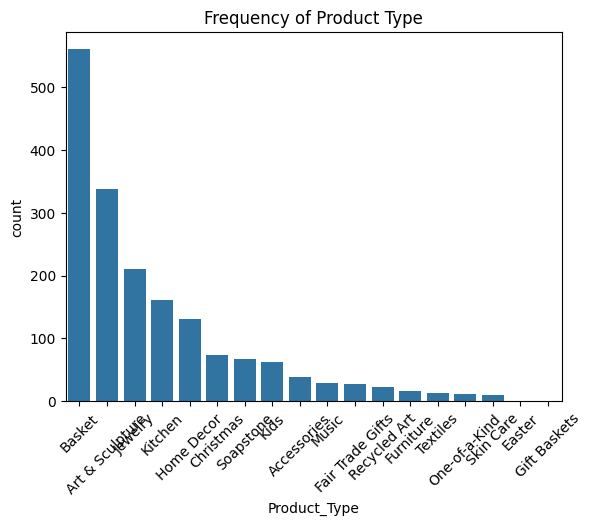

In [15]:
sns.countplot(data=df,x='Product_Type',order=df['Product_Type'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Frequency of Product Type')
plt.show()

### Analysis Frequency of Product Type

The x axis "Product_Type", so the distribution plot describe the numbers of buying the products by the customers.The "Product_Type" increasing demand for "Basket".Customers continuously buying "Basket".Nevertheless each products are slowly  selling  for customers and not buying the product as the "Gift Basket"

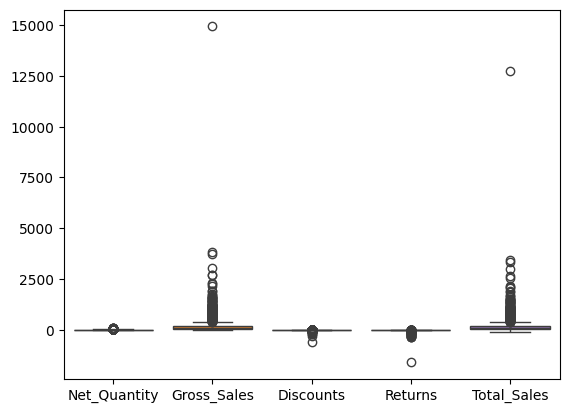

In [16]:
sns.boxplot(data=df)
plt.show()

#### Checking the Outliers 
 
 ##### To see the outliers in :

 a) Net_Quantity

 b) Gross_Sales

 c) Discounts
 
 d) Returns  

 e) Total_Sales 


 To remove the Outliers 

 1) Q1,Q2,Q3 method 

 2) find IQR  

 3) calculate upper limit and lower limit 

 4) check outlier using outlier function 
 
 5) remove outliers using "df.drop()"


In [17]:
Q1=df['Net_Quantity'].quantile(0.25)
Q2=df['Net_Quantity'].quantile(0.50)
Q3=df['Net_Quantity'].quantile(0.75)
print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['Net_Quantity']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier        

1.0 2.0 4.0
3.0
8.5
-3.5


[34,
 13,
 12,
 17,
 47,
 17,
 20,
 90,
 10,
 11,
 30,
 19,
 15,
 37,
 33,
 20,
 32,
 17,
 9,
 11,
 58,
 58,
 96,
 15,
 9,
 30,
 32,
 18,
 14,
 10,
 69,
 10,
 15,
 18,
 11,
 12,
 13,
 15,
 59,
 9,
 11,
 9,
 25,
 11,
 24,
 10,
 11,
 9,
 11,
 18,
 19,
 16,
 16,
 9,
 16,
 15,
 18,
 25,
 24,
 9,
 18,
 13,
 42,
 31,
 20,
 15,
 40,
 19,
 13,
 18,
 12,
 14,
 9,
 9,
 11,
 12,
 9,
 10,
 22,
 10,
 9,
 22,
 13,
 21,
 25,
 17,
 18,
 16,
 25,
 17,
 45,
 10,
 14,
 17,
 10,
 12,
 12,
 29,
 9,
 16,
 21,
 11,
 13,
 18,
 16,
 11,
 16,
 16,
 9,
 11,
 9,
 16,
 14,
 10,
 9,
 18,
 13,
 11,
 29,
 21,
 16,
 16,
 13,
 15,
 10,
 15,
 15,
 15,
 12,
 22,
 9,
 13,
 13,
 13,
 9,
 19,
 12,
 12,
 20,
 9,
 12,
 9,
 12,
 13,
 10,
 10,
 16,
 15,
 16,
 14,
 10,
 13,
 9,
 10,
 15,
 13,
 11,
 11,
 10,
 12,
 9,
 10,
 9,
 9,
 10]

In [18]:
df=df[(df['Net_Quantity']>=lower)& (df['Net_Quantity']<=upper)]

In [19]:
outlier=[]
for x in df['Net_Quantity']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier  

[]

In [20]:
# 'Gross Sales'
Q1=df['Gross_Sales'].quantile(0.25)
Q2=df['Gross_Sales'].quantile(0.50)
Q3=df['Gross_Sales'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)


outlier=[]
for x in df['Gross_Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

44.0 88.0 170.0
126.0
359.0
-145.0


[1625.0,
 1467.0,
 1660.0,
 1225.0,
 1155.0,
 1125.0,
 1152.0,
 1050.0,
 1030.0,
 1225.0,
 990.0,
 1050.0,
 952.0,
 925.0,
 1150.0,
 1179.0,
 960.0,
 945.0,
 879.0,
 876.5,
 875.0,
 900.0,
 812.0,
 1035.0,
 770.0,
 775.0,
 770.0,
 740.0,
 700.0,
 696.0,
 725.0,
 700.0,
 645.0,
 631.0,
 638.0,
 625.0,
 636.0,
 625.0,
 891.0,
 600.0,
 580.0,
 576.0,
 574.0,
 565.0,
 564.0,
 575.0,
 550.0,
 588.0,
 590.0,
 544.0,
 550.0,
 550.0,
 550.0,
 525.0,
 525.0,
 522.0,
 564.0,
 525.0,
 506.0,
 500.0,
 500.0,
 460.0,
 460.0,
 460.0,
 476.0,
 450.0,
 450.0,
 450.0,
 460.0,
 458.0,
 536.0,
 440.0,
 440.0,
 440.0,
 615.0,
 450.0,
 408.0,
 440.0,
 410.0,
 432.0,
 385.0,
 385.0,
 414.0,
 379.0,
 374.0,
 384.0,
 380.0,
 370.0,
 428.0,
 396.0,
 360.0,
 360.0,
 370.0,
 364.0,
 360.0,
 440.0,
 440.0,
 365.0,
 408.0,
 390.0,
 564.0,
 380.0]

In [21]:
df=df[(df['Gross_Sales']>=lower) & (df['Gross_Sales']<=upper)]

In [22]:

outlier=[]
for x in df['Gross_Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [23]:
df=df[(df['Gross_Sales']>=lower) & (df['Gross_Sales']<=upper)]

In [24]:

outlier=[]
for x in df['Gross_Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [25]:
#  'Discounts'
Q1=df[ 'Discounts'].quantile(0.25)
Q2=df[ 'Discounts'].quantile(0.50)
Q3=df[ 'Discounts'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)


outlier=[]
for x in df[ 'Discounts']:
 if((x>upper or (x<lower))):
    outlier.append(x)
outlier

-4.43 0.0 0.0
4.43
6.645
-11.075


[-11.6,
 -17.5,
 -17.5,
 -12.6,
 -35.0,
 -35.0,
 -22.0,
 -22.0,
 -16.2,
 -46.4,
 -11.41,
 -15.2,
 -38.4,
 -22.8,
 -70.0,
 -23.4,
 -12.0,
 -14.39,
 -14.4,
 -13.6,
 -28.8,
 -15.21,
 -15.31,
 -20.4,
 -15.2,
 -27.5,
 -12.5,
 -15.6,
 -11.6,
 -14.6,
 -19.69,
 -11.6,
 -24.0,
 -24.0,
 -24.0,
 -24.0,
 -19.5,
 -15.19,
 -14.0,
 -23.2,
 -19.6,
 -14.4,
 -22.0,
 -22.0,
 -13.01,
 -12.1,
 -13.4,
 -13.6,
 -20.5,
 -20.4,
 -16.79,
 -19.8,
 -14.39,
 -19.5,
 -19.5,
 -12.4,
 -11.6,
 -14.4,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -18.5,
 -16.23,
 -11.3,
 -11.6,
 -14.0,
 -17.49,
 -17.5,
 -17.5,
 -17.5,
 -17.5,
 -17.5,
 -17.5,
 -17.4,
 -17.4,
 -24.0,
 -16.8,
 -16.5,
 -16.5,
 -16.5,
 -16.5,
 -37.0,
 -37.0,
 -37.0,
 -15.2,
 -13.68,
 -14.5,
 -14.5,
 -14.5,
 -14.5,
 -14.5,
 -14.4,
 -14.4,
 -31.2,
 -13.6,
 -13.6,
 -13.49,
 -13.5,
 -13.0,
 -13.0,
 -20.4,
 -12.8,
 -11.14,
 -12.5,
 -12.5,
 -12.5,
 -12.5,
 -12.5,
 -18.75,
 -11.6,
 -11.6,
 -11.6,
 -11.6,
 -11.5,
 -11.5,
 

In [26]:
df=df[(df[ 'Discounts']>=lower)&(df[ 'Discounts']<=upper)]

In [27]:

outlier=[]
for x in df[ 'Discounts']:
 if((x>upper or (x<lower))):
    outlier.append(x)
outlier

[]

In [28]:
Q1=df['Returns'].quantile(0.25)
Q2=df['Returns'].quantile(0.50)
Q3=df['Returns'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['Returns']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

0.0 0.0 0.0
0.0
0.0
0.0


[-34.0,
 -38.88,
 -38.0,
 -38.0,
 -104.0,
 -38.0,
 -34.0,
 -38.0,
 -43.5,
 -128.0,
 -58.5,
 -34.2,
 -57.6,
 -140.0,
 -110.0,
 -56.0,
 -110.0,
 -37.12,
 -44.0,
 -10.8,
 -42.0,
 -34.2,
 -58.0,
 -34.0,
 -32.0,
 -54.0,
 -232.0,
 -28.0,
 -26.25,
 -44.0,
 -48.0,
 -28.0,
 -46.0,
 -68.4,
 -34.0,
 -38.0,
 -34.0,
 -28.0,
 -56.0,
 -14.4,
 -26.0,
 -34.0,
 -48.0,
 -1.0,
 -195.0,
 -28.0,
 -28.79,
 -25.19,
 -28.0,
 -16.5,
 -106.25]

In [29]:
df=df[(df['Returns']>=lower) &(df['Returns']<=upper)]

In [30]:
outlier=[]
for x in df['Returns']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier

[]

In [31]:
Q1=df['Total_Sales'].quantile(0.25)
Q2=df['Total_Sales'].quantile(0.50)
Q3=df['Total_Sales'].quantile(0.75)

print(Q1,Q2,Q3)

IQR=Q3-Q1
print(IQR)

upper=Q3+1.5*IQR
print(upper)
lower=Q1-1.5*IQR
print(lower)

outlier=[]
for x in df['Total_Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier        

38.0 68.4 129.2
91.19999999999999
266.0
-98.79999999999998


[350.0,
 350.0,
 350.0,
 350.0,
 348.0,
 348.0,
 348.0,
 344.0,
 336.0,
 332.85,
 330.0,
 330.0,
 330.0,
 319.0,
 319.0,
 315.0,
 310.0,
 307.0,
 307.0,
 305.5,
 300.0,
 298.0,
 296.0,
 295.6,
 293.0,
 290.0,
 288.0,
 288.0,
 288.0,
 285.0,
 278.4,
 278.39,
 273.68,
 272.0,
 272.0,
 271.2,
 270.0,
 268.48]

In [32]:
df=df[(df['Total_Sales']>=lower) & (df['Total_Sales']<=upper)]

In [33]:

outlier=[]
for x in df['Total_Sales']:
    if((x>upper or (x<lower))):
        outlier.append(x)
outlier   

[]

## Reset Dataset

Using "df.reset_index(drop=True,inplace=True)"

In [34]:
df.reset_index(drop=True,inplace=True)

In [35]:
df.head()

,Product_Type,Net_Quantity,Gross_Sales,Discounts,Returns,Total_Sales
0,Home Decor,4,272.0,-6.79,0.0,265.21
1,Home Decor,4,272.0,-6.80,0.0,265.20
2,Home Decor,3,264.0,0.00,0.0,264.00
3,Kitchen,2,264.0,0.00,0.0,264.00
4,Music,4,256.0,0.00,0.0,256.00


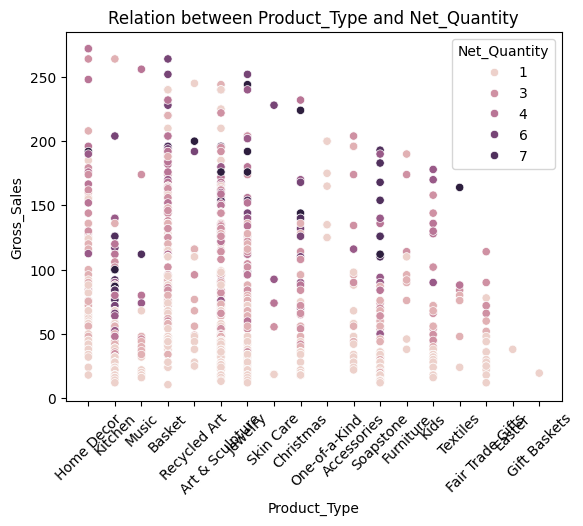

In [36]:
sns.scatterplot(data=df,x='Product_Type',y='Gross_Sales',hue='Net_Quantity')
plt.xticks(rotation=45)
plt.title("Relation between Product_Type and Net_Quantity")
plt.show()

#### Describe the Scatter plot

This scatter plot shows the relation between 

"Product_Type" and "Gross_Sales",with color intensity 

representing "Net_Quantity" sold.

Gross sales vary significantly across product 

categories. Categories such as Basket, Art & Sculpture, 

and Home Decor show higher concentration of points in 

the upper sales range, indicating stronger revenue 

performance.

Some extreme values (above 250 in gross sales) are 

visible, which may represent bulk purchases or 

high-value transactions.

Categories like Gift Baskets and Fair Trade Gifts appear

 to have relatively lower gross sales overall.

In [37]:
corr=df.corr(numeric_only=True)
print(corr)

              Net_Quantity  Gross_Sales  Discounts  Returns  Total_Sales
Net_Quantity      1.000000     0.415956  -0.289308      NaN     0.406245
Gross_Sales       0.415956     1.000000  -0.195587      NaN     0.999036
Discounts        -0.289308    -0.195587   1.000000      NaN    -0.152342
Returns                NaN          NaN        NaN      NaN          NaN
Total_Sales       0.406245     0.999036  -0.152342      NaN     1.000000


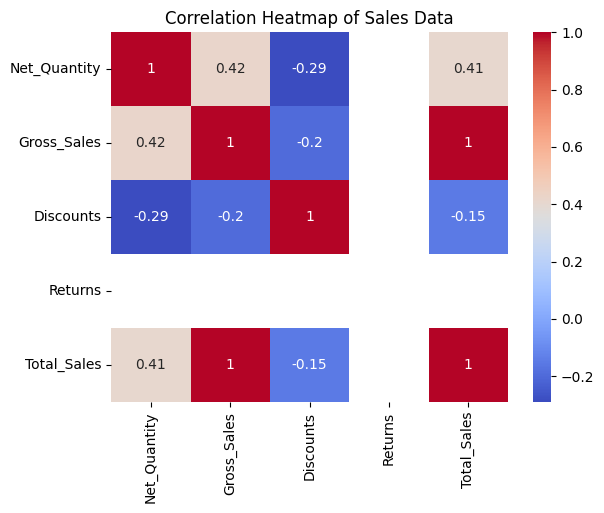

In [38]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap of Sales Data')
plt.show()

#### Correlation Analysis 

Relationship between key variables:

1) Gross Sales vs Total Net Sales

2) Discounts vs Total Net Sales

3) Returns vs Net Quantity

findings:

a) Strong positive correlation between Gross Sales and 

Total Net Sales (as expected).

b) Discounts show a negative relationship with net revenue.

c) Returns negatively affect Net Quantity and final revenue.

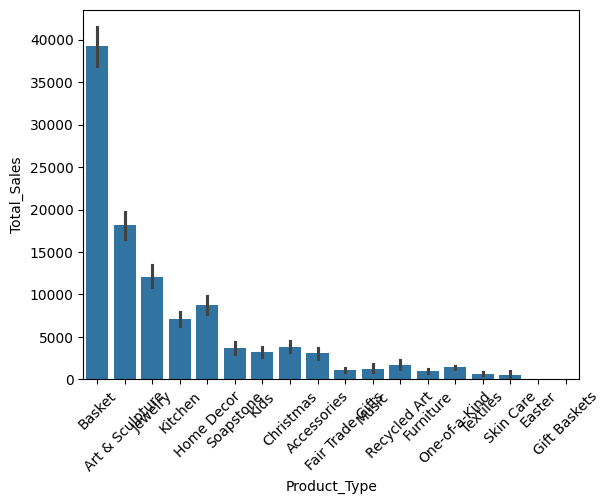

In [39]:
sns.barplot(data=df,x='Product_Type',y='Total_Sales',order=df['Product_Type'].value_counts().index,estimator=np.sum)
plt.xticks(rotation=45)
plt.show()

#### Product Type vs Total Sales

This bar chart shows "Total Sales" aggregated by "Product Type".

a) X-axis → Product Type

b) Y-axis → Total Sales (sum of all sales for each 

product type)

c) Bars are ordered by frequency of product types

d) Taller bar = higher contribution to total sales

#### Key Insights from the Plot

1) Basket has the highest total sales among all product 

types.

2) Art & Sculpture is the second highest, making it a 

strong revenue contributor.

3) Jewelry and Kitchen also perform well, but  

significantly lower than Basket.




In [40]:
revenue=df.groupby('Product_Type')['Total_Sales'].sum().reset_index()
revenue

,Product_Type,Total_Sales
0,Accessories,3075.78
1,Art & Sculpture,18148.48
2,Basket,39272.90
3,Christmas,3816.21
4,Easter,34.20
5,Fair Trade Gifts,1075.45
6,Furniture,1005.91
7,Gift Baskets,19.50
8,Home Decor,8739.21
9,Jewelry,12020.14


In [41]:
average_price=df.groupby('Product_Type')['Total_Sales'].mean()
average_price

Product_Type
Accessories          87.879429
Art & Sculpture      79.949251
Basket              114.833041
Christmas            76.324200
Easter               34.200000
Fair Trade Gifts     44.810417
Furniture           100.591000
Gift Baskets         19.500000
Home Decor          100.450690
Jewelry              71.125089
Kids                 53.085667
Kitchen              57.779431
Music                55.873913
One-of-a-Kind       162.222222
Recycled Art         87.028000
Skin Care            71.281250
Soapstone            58.874032
Textiles             77.555556
Name: Total_Sales, dtype: float64

#### Revenue Analysis 

1) Data was grouped by "Product Type" to evaluate 

category-level performance.

2) Total revenue was calculated for each category using  

"Total Sales".

3) Best-performing product types were identified based 

on overall contribution to revenue.

#### Key Observations:

a) Art & Sculpture generates high gross sales and 

contributes significantly to total revenue.

b) Some Kitchen products show low or negative net sales 

due to high returns.

c) Revenue contribution varies significantly across 

categories.



## Feature Engineering 


In [42]:
df.Product_Type.nunique()

18

### Encoding using LabelEncoder 

#### Encode Product_Type

To convert categorical values in numerical format

In [43]:
from sklearn.preprocessing import LabelEncoder

In [44]:
le=LabelEncoder()

In [45]:
df['Product_Type']=le.fit_transform(df['Product_Type'])

### Scaling the dataset 

#### Define X and Y  :

1) x : to decide first "Dependent Variable" and then "df.

drop" to the categorical values in axis 1.

2) y : to add dropped values. 

3) Using  the "MinmaxScaler" to "fit_transform" method  

by the x Variable.

4) create x2 Variable and convert on "pd.DataFrame" 

then  include numerical column names. 

5) Add "x2,y" in axis=1 using "pd.concat"

6) checking "max,min"  using  "describe()"

In [46]:
x=df.drop(['Total_Sales','Product_Type'],axis=1)

In [47]:
y=df[['Total_Sales','Product_Type']]

,Net_Quantity,Gross_Sales,Discounts,Returns
0,4,272.0,-6.79,0.0
1,4,272.0,-6.80,0.0
2,3,264.0,0.00,0.0
3,2,264.0,0.00,0.0
4,4,256.0,0.00,0.0
...,...,...,...,...
1255,1,12.0,0.00,0.0
1256,1,12.0,0.00,0.0
1257,1,12.0,0.00,0.0
1258,1,12.0,0.00,0.0


In [49]:
y

,Total_Sales,Product_Type
0,265.21,8
1,265.20,8
2,264.00,8
3,264.00,11
4,256.00,12
...,...,...
1255,12.00,9
1256,12.00,16
1257,12.00,11
1258,12.00,5


In [50]:
from sklearn.preprocessing import MinMaxScaler

In [51]:
scaler=MinMaxScaler(feature_range=(0,1))

In [52]:
x1=scaler.fit_transform(x)
x1

array([[0.42857143, 1.        , 0.38272727, 0.        ],
       [0.42857143, 1.        , 0.38181818, 0.        ],
       [0.28571429, 0.96940727, 1.        , 0.        ],
       ...,
       [0.        , 0.00573614, 1.        , 0.        ],
       [0.        , 0.00573614, 1.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        ]], shape=(1260, 4))

In [53]:
x2=pd.DataFrame(x1,columns=['Net_Quantity','Gross_Sales','Discounts','Returns'])
x2

,Net_Quantity,Gross_Sales,Discounts,Returns
0,0.428571,1.000000,0.382727,0.0
1,0.428571,1.000000,0.381818,0.0
2,0.285714,0.969407,1.000000,0.0
3,0.142857,0.969407,1.000000,0.0
4,0.428571,0.938815,1.000000,0.0
...,...,...,...,...
1255,0.000000,0.005736,1.000000,0.0
1256,0.000000,0.005736,1.000000,0.0
1257,0.000000,0.005736,1.000000,0.0
1258,0.000000,0.005736,1.000000,0.0


In [54]:
x3=pd.concat([x2,y],axis=1)
x3

,Net_Quantity,Gross_Sales,Discounts,Returns,Total_Sales,Product_Type
0,0.428571,1.000000,0.382727,0.0,265.21,8
1,0.428571,1.000000,0.381818,0.0,265.20,8
2,0.285714,0.969407,1.000000,0.0,264.00,8
3,0.142857,0.969407,1.000000,0.0,264.00,11
4,0.428571,0.938815,1.000000,0.0,256.00,12
...,...,...,...,...,...,...
1255,0.000000,0.005736,1.000000,0.0,12.00,9
1256,0.000000,0.005736,1.000000,0.0,12.00,16
1257,0.000000,0.005736,1.000000,0.0,12.00,11
1258,0.000000,0.005736,1.000000,0.0,12.00,5


In [55]:
x3.describe()

,Net_Quantity,Gross_Sales,Discounts,Returns,Total_Sales,Product_Type
count,1260.000000,1260.000000,1260.000000,1260.0,1260.000000,1260.00000
mean,0.150340,0.290086,0.862431,0.0,84.844357,5.84127
std,0.215786,0.223391,0.235917,0.0,57.965189,4.81956
min,0.000000,0.000000,0.000000,0.0,10.500000,0.00000
25%,0.000000,0.105163,0.745455,0.0,37.807500,2.00000
50%,0.000000,0.219885,1.000000,0.0,68.000000,3.00000
75%,0.285714,0.438815,1.000000,0.0,125.000000,9.00000
max,1.000000,1.000000,1.000000,0.0,265.210000,17.00000


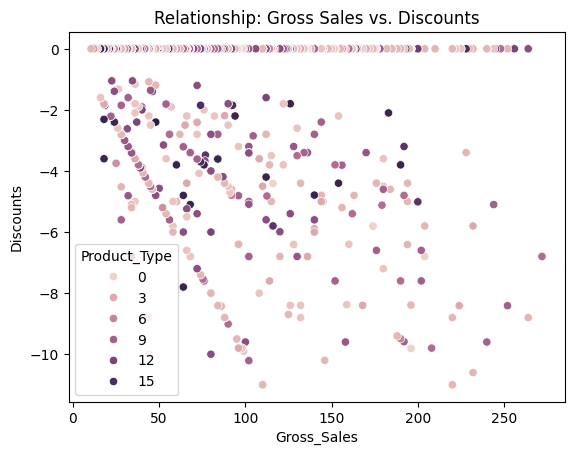

In [56]:
sns.scatterplot(data=df, x='Gross_Sales', y='Discounts', hue='Product_Type')
plt.title('Relationship: Gross Sales vs. Discounts')
plt.show()

#### Relation  Discount and Gross_Sales plot Explanation

a) X-axis → Gross_Sales

b) Y-axis → Discounts

c) Color (hue) → Product_Type (encoded values)


#### Explanation :

The scatter plot indicates a weak relationship between \

Gross Sales and Discounts. While higher discounts 

sometimes coincide with moderate sales, there is no 

strong linear trend. This suggests that discounts alone 

do not determine sales performance. Other factors such 

as product demand, category popularity, and pricing 

strategy may play significant roles.

### plot shows:

1) Discount are mostly negative.

2) No strong relationship between Gross_Sales and 

Discount .

3) Some extreme discount values.

4) Product types are mixed.

In [57]:
df

,Product_Type,Net_Quantity,Gross_Sales,Discounts,Returns,Total_Sales
0,8,4,272.0,-6.79,0.0,265.21
1,8,4,272.0,-6.80,0.0,265.20
2,8,3,264.0,0.00,0.0,264.00
3,11,2,264.0,0.00,0.0,264.00
4,12,4,256.0,0.00,0.0,256.00
...,...,...,...,...,...,...
1255,9,1,12.0,0.00,0.0,12.00
1256,16,1,12.0,0.00,0.0,12.00
1257,11,1,12.0,0.00,0.0,12.00
1258,5,1,12.0,0.00,0.0,12.00


## Key Insights from the Dataset

1) ### Revenue Concentration

a) Revenue is highly concentrated in a few product 

categories.

b) Basket and Art & Sculpture generate the highest total 

sales.

c) Several categories contribute minimally to total

 revenue.

2) ###  Impact of Discounts

a) Discounts are mostly recorded as negative values 

(price reductions).

b) There is no strong linear relationship between Gross 

Sales and Discounts.

c) High discounts do not consistently lead to higher 

sales.

d) Some categories rely heavily on discounting 

strategies.

3) ### Returns & Negative Net Quantity

a) Some products show high return values.

b) Negative Net Quantity indicates:
    
    * - Excess returns
    
    * - Data corrections
    
    * - Possible product quality issues


4) ### Correlation Findings

a) Strong positive correlation between:

   1) Gross Sales and Total Net Sales (expected).

 b) Negative relationship between:

  1) Discounts and Total Net Sales.

   2) Returns and Net Quantity.

5) ### Outliers

a) A few transactions show extremely high sales values.

b) Some transactions show unusually high discounts.

c) These may represent:

    1) Bulk purchases

     2)Special promotions

6) ###  Product Type Behavior

   1) Product types show similar discount patterns.

   2) No single category dominates discount usage.

3) Some lower-performing categories may require:

     a) Better marketing

     b) Pricing review

   c) Inventory adjustments


## Conclusion 

This exploratory data analysis provided meaningful 

insights into product performance, pricing behavior, and 

revenue distribution.

#### Key conclusions:

a) Certain categories are strong revenue drivers.

b) Returns and discounts significantly affect 

profitability.

c) Some transactions require business review due to 

negative sales or extreme values.

d) Feature engineering and proper preprocessing are    

essential before building predictive models.


Overall, the dataset reveals clear patterns that can support better business decisions and predictive modeling.


